# Deep Neural Network from Scratch
### S&P 500 Daily Direction Prediction · NumPy & Pandas

---

**Goal:** Build a fully connected DNN using only NumPy to predict whether the S&P 500 closes up or down on a given day.

**Stack:** `numpy`, `pandas`, `yfinance`, `matplotlib`

| Attribute | Value |
|---|---|
| Architecture | MLP: 10 → 64 → 32 → 1 |
| Activation (hidden) | tanh |
| Activation (output) | sigmoid |
| Loss | Binary Cross-Entropy |
| Optimizer | Full-Batch Gradient Descent |
| Learning Rate | 1/L (Lipschitz smooth) |

In [49]:
import yfinance as yf
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## 1. Problem Setup

We define a supervised learning problem over daily SPY log returns. The dataset is:

$$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$$

where each sample maps a window of 10 lagged log returns to a binary direction label:

$$\mathbf{x}_i = [r_{t-10},\, r_{t-9},\, \ldots,\, r_{t-1}] \in \mathbb{R}^{10}$$

$$y_i = \mathbf{1}[r_t > 0] \in \{0, 1\}$$

Log returns are defined as:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple returns because they are:
- **Additive over time** — $r_{t,T} = \sum_{s=t}^{T} r_s$
- **Approximately zero-centered**, which suits our tanh activation
- **Stationary** (roughly), which is a desirable property for ML inputs

### Train/Test Split

The split is strictly **chronological** — no shuffling. First 80% for training, last 20% for test. Shuffling would introduce **look-ahead bias**, rendering the model useless in production.

In [61]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use('dark_background')
ACCENT = '#00d4aa'
ACCENT2 = '#7c6af7'
ACCENT3 = '#ff6b35'

# Pull SPY data
df = yf.download('SPY', start='2015-01-01', end='2025-01-01', auto_adjust=True)

# Log returns — squeeze to 1D
log_returns = np.log(df['Close'] / df['Close'].shift(1)).squeeze().dropna()
log_returns_array = log_returns.values.reshape(-1)

print(f"Log return series shape: {log_returns_array.shape}")

# Feature matrix: sliding window of 10 lagged returns
def create_feature_matrix(returns, window=10):
    X, y = [], []
    for i in range(window, len(returns)):
        X.append(returns[i-window:i])
        y.append(1 if returns[i] > 0 else 0)
    return np.array(X), np.array(y).reshape(-1, 1)

X, y = create_feature_matrix(log_returns_array)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"Class balance (train): {y_train.mean():.3f} up / {1 - y_train.mean():.3f} down")

[*********************100%***********************]  1 of 1 completed

Log return series shape: (2515,)
X_train: (2004, 10)  |  y_train: (2004, 1)
X_test:  (501, 10)   |  y_test:  (501, 1)
Class balance (train): 0.540 up / 0.460 down


## 2. Architecture & Forward Pass

The network maps $\mathbf{x} \in \mathbb{R}^{10}$ through $L = 3$ layers. Let $\ell \in \{1, 2, \ldots, L\}$ index each layer with depth $L$ and height $d_\ell$.

### Layer-to-layer propagation

For each layer $\ell$:

$$\vec{s}^{[\ell]} = W^{[\ell]}\, \vec{x}^{[\ell-1]} + \vec{b}^{[\ell]}$$

$$\vec{x}^{[\ell]} = \sigma\!\left(\vec{s}^{[\ell]}\right) \quad \text{(component-wise)}$$

The Jacobian of $\vec{x}^{[\ell]}$ with respect to $\vec{s}^{[\ell]}$ is a **diagonal matrix**:

$$\frac{\partial \vec{x}^{[\ell]}}{\partial \vec{s}^{[\ell]}} = \text{diag}\!\left(\sigma'\!\left(\vec{s}^{[\ell]}\right)\right)$$

This is diagonal because each $x_i^{[\ell]}$ depends only on its own pre-activation $s_i^{[\ell]}$ — activations are applied component-wise.

### Full forward pass (batched)

| Step | Operation | Shape |
|---|---|---|
| Input | $X$ | $(N, 10)$ |
| Pre-act 1 | $Z^{[1]} = X W^{[1]} + b^{[1]}$ | $(N, 64)$ |
| Act 1 | $A^{[1]} = \tanh(Z^{[1]})$ | $(N, 64)$ |
| Pre-act 2 | $Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}$ | $(N, 32)$ |
| Act 2 | $A^{[2]} = \tanh(Z^{[2]})$ | $(N, 32)$ |
| Pre-act 3 | $Z^{[3]} = A^{[2]} W^{[3]} + b^{[3]}$ | $(N, 1)$ |
| Output | $\hat{Y} = \sigma(Z^{[3]})$ | $(N, 1)$ |

## 3. Activation Functions

### Why tanh for hidden layers?

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \quad \tanh(z) \in (-1, 1)$$

- Output is **zero-centered** — log returns cluster near 0, so tanh is a natural fit
- The derivative $\tanh'(z) = 1 - \tanh^2(z)$ is clean and cheap to compute (reuses forward pass values)
- At depth $L=3$, vanishing gradients are not severe enough to prefer ReLU

### Why sigmoid for the output?

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad \sigma(z) \in (0, 1)$$

- Produces a valid **probability** for the binary direction prediction
- Required by binary cross-entropy loss

### Derivatives used in backprop

$$\tanh'(z) = 1 - \tanh^2(z)$$

$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Note: the sigmoid derivative cancels with BCE gradient, giving the clean residual $\hat{y} - y$ at the output layer.

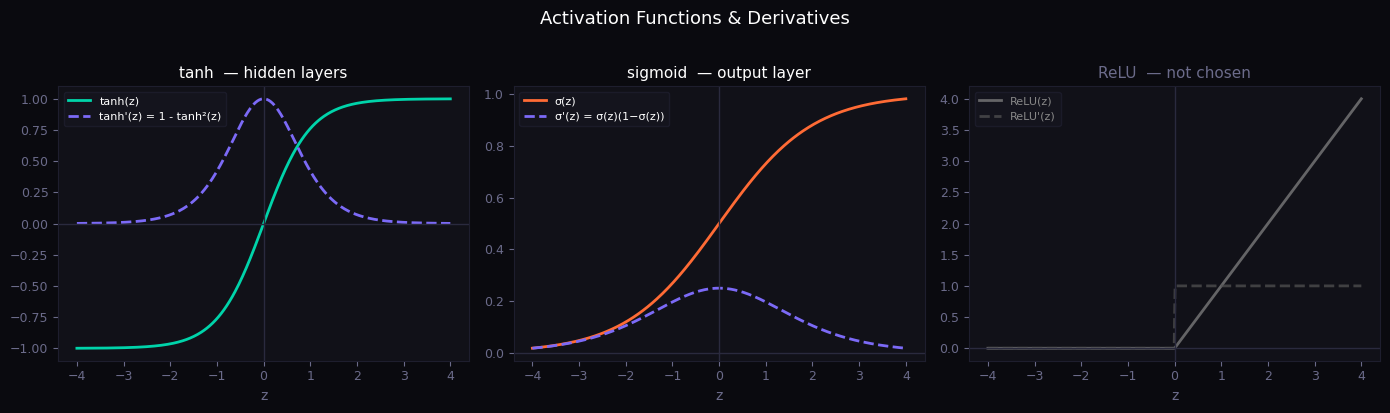

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0a0a0f')
for ax in axes:
    ax.set_facecolor('#111118')
    ax.tick_params(colors='#6b6b8a', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e1e2e')

z = np.linspace(-4, 4, 400)

# tanh
tanh_z = np.tanh(z)
tanh_dz = 1 - np.tanh(z)**2
axes[0].plot(z, tanh_z,  color=ACCENT,  lw=2,   label='tanh(z)')
axes[0].plot(z, tanh_dz, color=ACCENT2, lw=2, ls='--', label="tanh'(z) = 1 - tanh²(z)")
axes[0].axhline(0, color='#2a2a3e', lw=1)
axes[0].axvline(0, color='#2a2a3e', lw=1)
axes[0].set_title('tanh  — hidden layers', color='white', fontsize=11)
axes[0].legend(fontsize=8, labelcolor='white', facecolor='#16161f', edgecolor='#1e1e2e')
axes[0].set_xlabel('z', color='#6b6b8a')

# sigmoid
sig_z  = 1 / (1 + np.exp(-z))
sig_dz = sig_z * (1 - sig_z)
axes[1].plot(z, sig_z,  color=ACCENT3, lw=2,   label='σ(z)')
axes[1].plot(z, sig_dz, color=ACCENT2, lw=2, ls='--', label="σ'(z) = σ(z)(1−σ(z))")
axes[1].axhline(0, color='#2a2a3e', lw=1)
axes[1].axvline(0, color='#2a2a3e', lw=1)
axes[1].set_title('sigmoid  — output layer', color='white', fontsize=11)
axes[1].legend(fontsize=8, labelcolor='white', facecolor='#16161f', edgecolor='#1e1e2e')
axes[1].set_xlabel('z', color='#6b6b8a')

# ReLU (comparison)
relu_z  = np.maximum(0, z)
relu_dz = (z > 0).astype(float)
axes[2].plot(z, relu_z,  color='#888', lw=2,   label='ReLU(z)',   alpha=0.7)
axes[2].plot(z, relu_dz, color='#555', lw=2, ls='--', label="ReLU'(z)", alpha=0.7)
axes[2].axhline(0, color='#2a2a3e', lw=1)
axes[2].axvline(0, color='#2a2a3e', lw=1)
axes[2].set_title('ReLU  — not chosen', color='#6b6b8a', fontsize=11)
axes[2].legend(fontsize=8, labelcolor='#888', facecolor='#16161f', edgecolor='#1e1e2e')
axes[2].set_xlabel('z', color='#6b6b8a')

plt.suptitle('Activation Functions & Derivatives', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('activations.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

## 4. Loss Function — Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[ y_i \log(\hat{y}_i + \varepsilon) + (1 - y_i)\log(1 - \hat{y}_i + \varepsilon) \right]$$

$\varepsilon = 10^{-8}$ prevents $\log(0)$ instability.

### Gradient at output layer

By the chain rule, $\frac{\partial \mathcal{L}}{\partial W^{[L]}}$ requires $\frac{\partial \mathcal{L}}{\partial s^{[L]}}$:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial s^{[L]}} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \sigma'(s^{[L]}) = \hat{y} - y$$

The BCE + sigmoid derivative collapses to just the **residual** — clean and numerically stable.

$$\boxed{\delta^{[L]} = \frac{\partial \mathcal{L}}{\partial \vec{s}^{[L]}} = \hat{\mathbf{y}} - \mathbf{y}}$$

## 5. Backpropagation — Derivations

Following the notation from lecture with $\vec{\delta}^{[\ell]} = \frac{\partial \mathcal{L}}{\partial \vec{s}^{[\ell]}}$:

### Deriving $\delta^{[\ell]}$ recursively

The output gradient $\vec{\delta}^{[L]}$ is derived above. For earlier layers, applying the chain rule across the full depth:

$$\vec{\delta}^{[\ell]} \in \mathbb{R}^{1 \times d_\ell} = \frac{\partial \mathcal{L}}{\partial \vec{s}^{[\ell]}} = \frac{\partial \mathcal{L}}{\partial \vec{s}^{[L]}} \cdot \frac{\partial \vec{s}^{[L]}}{\partial \vec{s}^{[L-1]}} \cdots \frac{\partial \vec{s}^{[\ell+1]}}{\partial \vec{s}^{[\ell]}}$$

Each factor expands as:

$$\frac{\partial \vec{s}^{[\ell]}}{\partial \vec{s}^{[\ell-1]}} = W^{[\ell]}\, \text{diag}\!\left(\sigma'\!\left(\vec{s}^{[\ell-1]}\right)\right)$$

So the recursive update going backward is:

$$\boxed{\vec{\delta}^{[\ell-1]} = \left(\vec{\delta}^{[\ell]}\, W^{[\ell]}\right) \odot \sigma'\!\left(\vec{s}^{[\ell-1]}\right)}$$

where $\odot$ denotes **element-wise multiplication** (the diag matrix collapses to a Hadamard product in practice).

---

### Gradient w.r.t. weights $W^{[\ell]}$

$$\frac{\partial s_i^{[\ell]}}{\partial w_{kj}^{[\ell]}} = \begin{cases} x_j^{[\ell-1]} & k = i \\ 0 & k \neq i \end{cases}$$

Therefore:

$$\frac{\partial \mathcal{L}}{\partial w_{kj}^{[\ell]}} = \delta_k^{[\ell]} \cdot x_j^{[\ell-1]}$$

Which is the **outer product** of two vectors:

$$\frac{\partial \mathcal{L}}{\partial W^{[\ell]}} = \vec{x}^{[\ell-1]\top} \vec{\delta}^{[\ell]} \quad \in \mathbb{R}^{d_{\ell-1} \times d_\ell}$$

In batched form (averaging over $N$ samples):

$$\boxed{\frac{\partial \mathcal{L}}{\partial W^{[\ell]}} = \frac{1}{N}\, A^{[\ell-1]\top}\, \Delta^{[\ell]}}$$

---

### Gradient w.r.t. biases $b^{[\ell]}$

Since $\frac{\partial s_i^{[\ell]}}{\partial b_j^{[\ell]}} = \mathbf{1}[i = j]$, i.e. $\frac{\partial \vec{s}^{[\ell]}}{\partial \vec{b}^{[\ell]}} = I$:

$$\boxed{\frac{\partial \mathcal{L}}{\partial \vec{b}^{[\ell]}} = \vec{\delta}^{[\ell]}}$$

In batched form: mean over samples along axis 0.

---

### Gradient dimensions summary

| Gradient | Shape | Expression |
|---|---|---|
| $\delta^{[3]}$ | $(N, 1)$ | $\hat{Y} - y$ |
| $\partial \mathcal{L}/\partial W^{[3]}$ | $(32, 1)$ | $A^{[2]\top} \delta^{[3]} / N$ |
| $\partial \mathcal{L}/\partial b^{[3]}$ | $(1,)$ | $\text{mean}(\delta^{[3]})$ |
| $\delta^{[2]}$ | $(N, 32)$ | $(\delta^{[3]} W^{[3]\top}) \odot \tanh'(Z^{[2]})$ |
| $\partial \mathcal{L}/\partial W^{[2]}$ | $(64, 32)$ | $A^{[1]\top} \delta^{[2]} / N$ |
| $\partial \mathcal{L}/\partial b^{[2]}$ | $(32,)$ | $\text{mean}(\delta^{[2]})$ |
| $\delta^{[1]}$ | $(N, 64)$ | $(\delta^{[2]} W^{[2]\top}) \odot \tanh'(Z^{[1]})$ |
| $\partial \mathcal{L}/\partial W^{[1]}$ | $(10, 64)$ | $X^{\top} \delta^{[1]} / N$ |
| $\partial \mathcal{L}/\partial b^{[1]}$ | $(64,)$ | $\text{mean}(\delta^{[1]})$ |

## 6. Learning Rate — Lipschitz Smoothness

A function $f$ is **$L$-smooth** if its gradient is Lipschitz continuous:

$$\|\nabla f(x) - \nabla f(y)\| \leq L\|x - y\| \quad \forall\, x, y$$

For gradient descent, the theoretically optimal step size is $\eta^* = 1/L$.

For binary cross-entropy with sigmoid output, the curvature of the loss is bounded by the largest eigenvalue of the Hessian. The second derivative of the sigmoid function, which appears in the Hessian of the BCE loss, is bounded by $\frac{1}{4}$. 

We will just pick 1/4, but here's how you would typically do it: 

$$L = \lambda_{\max}$$

$$\boxed{\eta^* = \frac{1}{L} = \frac{1}{\lambda_{\max}}}$$

This guarantees convergence and avoids manual tuning.

In [ ]:
def init_weights():
    W1 = np.random.uniform(-0.5, 0.5, (10, 64))
    b1 = np.random.uniform(-0.5, 0.5, (64,))
    W2 = np.random.uniform(-0.5, 0.5, (64, 32))
    b2 = np.random.uniform(-0.5, 0.5, (32,))
    W3 = np.random.uniform(-0.5, 0.5, (32, 1))
    b3 = np.random.uniform(-0.5, 0.5, (1,))
    return W1, b1, W2, b2, W3, b3

def compute_lr(X):
    N = X.shape[0]
    eigenvalues = np.linalg.eigvalsh(X.T @ X)
    lambda_max = np.max(eigenvalues)
    L = lambda_max 
    return 1 / L

lr = compute_lr(X_train)
print(f"λ_max(XᵀX): {np.max(np.linalg.eigvalsh(X_train.T @ X_train)):.4f}")
print(f"L (smoothness constant): {1/lr:.6f}")
print(f"η* = 1/L: {lr:.6f}")

W1, b1, W2, b2, W3, b3 = init_weights()


λ_max(XᵀX): 0.4797
L (smoothness constant): 0.000060
η* = 1/L: 16710.529603


In [67]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X  @ W1 + b1                        # (N, 64)
    A1 = np.tanh(Z1)                         # (N, 64)
    Z2 = A1 @ W2 + b2                        # (N, 32)
    A2 = np.tanh(Z2)                         # (N, 32)
    Z3 = A2 @ W3 + b3                        # (N,  1)
    A3 = 1 / (1 + np.exp(-Z3))              # (N,  1)
    return Z1, A1, Z2, A2, Z3, A3

def backward(X, y, W1, b1, W2, b2, W3, b3,
             Z1, A1, Z2, A2, Z3, A3, lr):
    N = X.shape[0]

    # δ[3] = ŷ - y  (BCE + sigmoid derivative collapses)
    dZ3 = A3 - y                             # (N, 1)
    dW3 = A2.T @ dZ3 / N                    # (32, 1)
    db3 = dZ3.mean(axis=0)

    # δ[2] = (δ[3] W[3]ᵀ) ⊙ tanh'(Z[2])
    dZ2 = (dZ3 @ W3.T) * (1 - np.tanh(Z2)**2)   # (N, 32)
    dW2 = A1.T @ dZ2 / N                    # (64, 32)
    db2 = dZ2.mean(axis=0)

    # δ[1] = (δ[2] W[2]ᵀ) ⊙ tanh'(Z[1])
    dZ1 = (dZ2 @ W2.T) * (1 - np.tanh(Z1)**2)   # (N, 64)
    dW1 = X.T @ dZ1 / N                     # (10, 64)
    db1 = dZ1.mean(axis=0)

    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2
    W3 -= lr * dW3;  b3 -= lr * db3
    return W1, b1, W2, b2, W3, b3

def train(X, y, epochs=1000, lr=0.01):
    W1, b1, W2, b2, W3, b3 = init_weights()
    history = []

    for e in range(int(epochs)):
        Z1, A1, Z2, A2, Z3, A3 = forward(X, W1, b1, W2, b2, W3, b3)
        loss = -np.mean(y * np.log(A3 + 1e-8) + (1 - y) * np.log(1 - A3 + 1e-8))
        W1, b1, W2, b2, W3, b3 = backward(
            X, y, W1, b1, W2, b2, W3, b3, Z1, A1, Z2, A2, Z3, A3, lr)

        preds = (A3 > 0.5).astype(int)
        acc = np.mean(preds == y)
        history.append({'epoch': e, 'loss': loss, 'acc': acc})

        if e % 100 == 0:
            print(f"Epoch {e:4d} | Loss: {loss:.4f} | Acc: {acc:.4f}")

    return W1, b1, W2, b2, W3, b3, history

W1, b1, W2, b2, W3, b3, history = train(X_train, y_train, epochs=1000, lr=0.25)

Epoch    0 | Loss: 0.6935 | Acc: 0.4825
Epoch  100 | Loss: 0.6897 | Acc: 0.5394
Epoch  200 | Loss: 0.6895 | Acc: 0.5394
Epoch  300 | Loss: 0.6893 | Acc: 0.5399
Epoch  400 | Loss: 0.6891 | Acc: 0.5404
Epoch  500 | Loss: 0.6890 | Acc: 0.5409
Epoch  600 | Loss: 0.6888 | Acc: 0.5414
Epoch  700 | Loss: 0.6886 | Acc: 0.5424
Epoch  800 | Loss: 0.6885 | Acc: 0.5429
Epoch  900 | Loss: 0.6883 | Acc: 0.5434


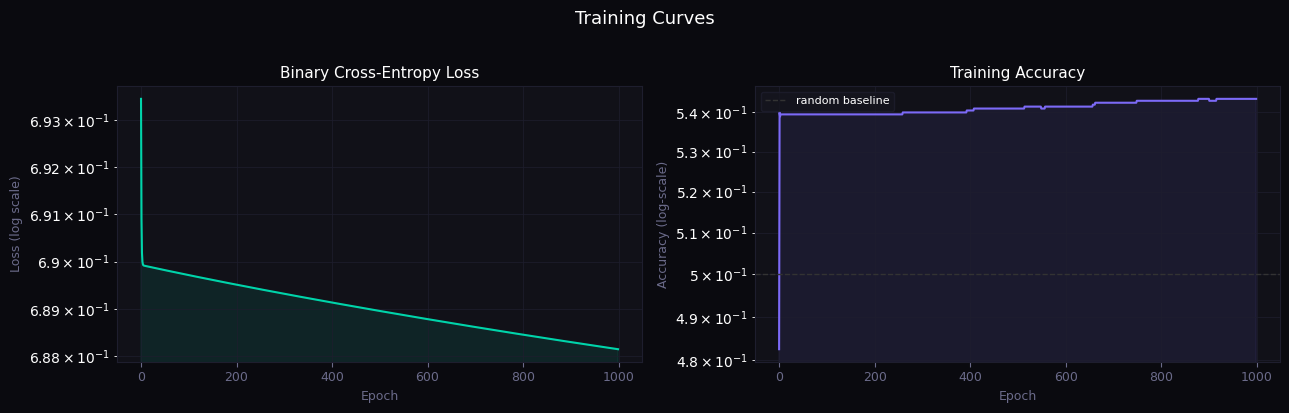

In [73]:
epochs_hist = [h['epoch'] for h in history]
losses      = [h['loss']  for h in history]
accs        = [h['acc']   for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0a0a0f')

for ax in axes:
    ax.set_facecolor('#111118')
    ax.tick_params(colors='#6b6b8a', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e1e2e')
    ax.grid(True, color='#1e1e2e', linewidth=0.5, which='both')

# Loss (log scale)
axes[0].plot(epochs_hist, losses, color=ACCENT, lw=1.5)
axes[0].fill_between(epochs_hist, losses, alpha=0.1, color=ACCENT)
axes[0].set_yscale('log')
axes[0].set_title('Binary Cross-Entropy Loss', color='white', fontsize=11)
axes[0].set_xlabel('Epoch', color='#6b6b8a', fontsize=9)
axes[0].set_ylabel('Loss (log scale)', color='#6b6b8a', fontsize=9)

# Accuracy
axes[1].plot(epochs_hist, accs, color=ACCENT2, lw=1.5)
axes[1].fill_between(epochs_hist, accs, alpha=0.1, color=ACCENT2)
axes[1].axhline(0.5, color='#333', lw=1, ls='--', label='random baseline')
axes[1].set_title('Training Accuracy', color='white', fontsize=11)
axes[1].set_xlabel('Epoch', color='#6b6b8a', fontsize=9)
axes[1].set_ylabel('Accuracy (log-scale)', color='#6b6b8a', fontsize=9)
axes[1].legend(fontsize=8, labelcolor='white', facecolor='#16161f', edgecolor='#1e1e2e')
axes[1].set_yscale('log')

plt.suptitle('Training Curves', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

In [74]:
_, _, _, _, _, A3_test = forward(X_test, W1, b1, W2, b2, W3, b3)
preds_test = (A3_test > 0.5).astype(int)
test_acc   = np.mean(preds_test == y_test)
test_loss  = -np.mean(y_test * np.log(A3_test + 1e-8) + (1 - y_test) * np.log(1 - A3_test + 1e-8))

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Baseline (always predict up): {y_test.mean():.4f}")


Test Loss:     0.6853
Test Accuracy: 0.5749
Baseline (always predict up): 0.5749
